In [13]:
from scipy import interpolate
from calculate_MIH_general import tms,readAF,computeMIH

In [14]:
#Each time series in an ascii txt file should contain two columns: time [sec] and surface elevation [m].
#examples:
tmsf="example_general/tms_00501.txt"
#tmsf="example_general/spletaD4_m.txt"
#tmsf="example_general/spletaD6_m.txt"
#tmsf="example_general/spletaD6_3x_m.txt"

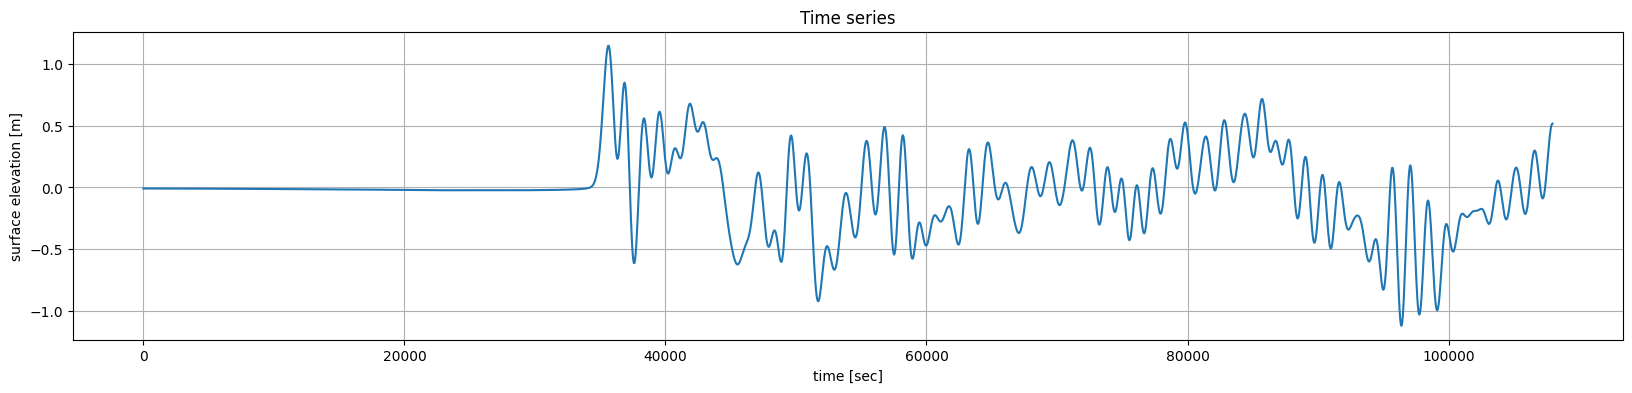

In [15]:
#inspect a plot for chosen time serie
import matplotlib.pyplot as plt
import numpy as np  
data=np.loadtxt(tmsf)
plt.figure(figsize=(20,4))
plt.plot(data[:,0],data[:,1])   
plt.xlabel('time [sec]')
plt.ylabel('surface elevation [m]')
plt.title('Time series')
plt.grid()
plt.show()

In [16]:
#read amplification factors
af=readAF("../ampfactors/global_ampf_v04.txt")
#printing the first 10 lines of the ampfactor file, which contains the location of the POIs and the corresponding amplification factors
print("".join(open("../ampfactors/global_ampf_v04.txt").readlines()[:10]))

#globalid lon lat neg 120 200 300 600 1000 1800 3600 pos 120 200 300 600 1000 1800 3600 prof name area previd
id00001 -16.385840 10.191670 neg 6.46 6.46 6.32 5.66 5.30 4.57 4.29 pos 5.96 5.86 5.67 5.20 4.78 4.30 3.69 real NEA nea12443 12443
id00002 -16.458330 10.358330 neg 6.46 6.46 6.32 5.66 5.30 4.57 4.29 pos 5.96 5.86 5.67 5.20 4.78 4.30 3.69 real NEA nea12449 12449
id00003 -16.558330 10.462500 neg 6.55 6.57 6.42 5.74 4.74 3.48 1.90 pos 5.84 5.65 5.38 4.75 4.15 3.50 2.80 real NEA nea12451 12451
id00004 -16.619200 10.616670 neg 6.56 6.61 6.46 6.17 5.51 3.30 1.34 pos 5.81 5.61 5.33 4.65 4.07 3.25 2.29 real NEA nea12453 12453
id00005 -16.721670 10.783330 neg 6.55 6.57 6.47 6.09 4.59 2.67 2.34 pos 5.82 5.62 5.35 4.66 4.03 3.20 2.43 real NEA nea12456 12456
id00006 -16.850000 10.914580 neg 6.55 6.57 6.47 6.09 4.59 2.67 2.34 pos 5.82 5.62 5.35 4.66 4.03 3.20 2.43 real NEA nea12458 12458
id00007 -17.025000 11.041410 neg 6.60 6.60 6.53 6.08 4.68 2.55 1.91 pos 5.85 5.66 5.40 4.75 4.07 3.18 2.

Prosessing mariogram from example_general/tms_00501.txt


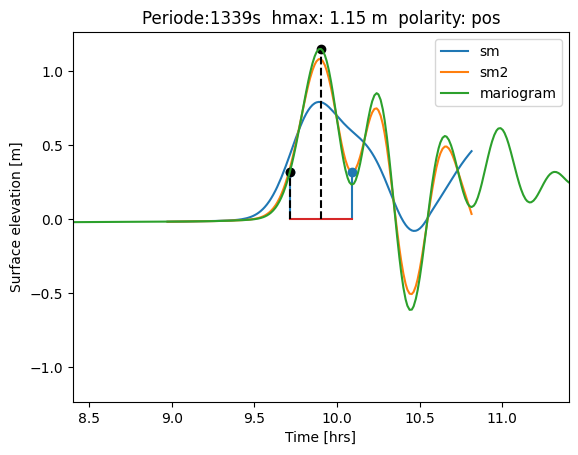


Inspect plot: plot/plot_tms_tms_00501_id03700_eta.png
MIH for mariogram example_general/tms_00501.txt is 3.8 m with offshore wave amplitude of 1.1 m, wave period 1339 s and amplification factor 3.27.


<Figure size 640x480 with 0 Axes>

In [17]:
# calculate MIH for the chosen time series
ampfact_id="id03700"
plot=True
plot_dir="plot"
plot_name="plot_tms_"+tmsf.split("/")[-1].split(".")[0]+"_"+ampfact_id
results=tms(tmsf, af, ampfact_id, plot, plot_dir, plot_name,tsample=5)   


### HySEA - calculating MIH from multiple time series using existing example 


Run postprocessing script to extract wave parameters for all the time series and save them in a txt file (wave periode, max wave height, amplification factor, MIH)
Ouput from HySEA (mariograms) are found in example_HySEA/result_ts.nc



In [18]:
#import subprocess
#subprocess.run(["wsl","../postprocess_HySEA/postprocess_HySea", "example_HySEA/result_ts.nc"], check=True)

import os
os.system("../postprocess_HySEA/postprocess_HySea example_HySEA/result_ts.nc")

1

The command above will create a the file with wave characteristics needed for calculating MIH with amplification factors
First 10 lines shown below 

In [19]:
print("".join(open("example_HySEA/result_ts.nc.offshore.txt").readlines()[:10]))

ID lon lat depth max_ssh min_ssh period polarity return_code
    1	+120.8333	+18.6672	 47	0.121	-0.155	 1357	 1	3
    2	+120.8721	+18.6333	-54	54.499	54.499	    0	 0	1
    3	+120.9333	+18.5795	123	0.149	-0.212	 1868	 1	3
    4	+121.0000	+18.6215	199	0.154	-0.183	 1197	 1	3
    5	+121.0667	+18.6484	105	0.221	-0.194	 1308	 1	3
    6	+121.1667	+18.6492	 91	0.276	-0.262	 2367	 1	3
    7	+121.2333	+18.6119	 50	0.293	-0.308	 2055	 1	3
    8	+121.2878	+18.5667	 26	0.503	-0.342	 2243	-1	3
    9	+121.3347	+18.5333	 10	0.594	-0.478	 2261	 1	3



In [20]:
#a id file that connects the location of the POIs in HySEA with the corresponding id in the ampfact file is also needed, first 10 lines shown below
print("".join(open("example_HySEA/result_ts.nc_id.txt").readlines()[:10]))

4045
id02943	66.0	25.2333
id03068	69.8444	20.9333
id03069	69.6444	21.1667
id03070	69.4333	21.3667
id03071	69.2111	21.6
id03072	69.0083	21.8333
id03073	68.8	22.0444
id03074	68.6	22.2667
id03075	68.3333	22.4333



In [21]:
from calculate_MIH_HySEA import computeMIH
tms_file="example_HySEA/result_ts.nc"                 #output from HySEA, location of POIs from ampfact
tms_id_file="example_HySEA/result_ts.nc_id.txt"       #input id file, location of POIs in HySEA with corresponding id
out_results="example_HySEA/calculated_MIH_HySEA.txt"  #name of outputfile
computeMIH(af,tms_file, tms_id_file, out_results)

nonzero: 2210
The computed MIH for mariograms from HySEA (file: example_HySEA/result_ts.nc) is saved in example_HySEA/calculated_MIH_HySEA.txt


In [22]:
print("".join(open("example_HySEA/calculated_MIH_HySEA.txt").readlines()[:10]))

#id lon lat MIH hmax period
id02943 66.000000 25.233300 0.42 0.12 1357
id03068 69.844400 20.933300 -1.00 -1.00 -1
id03069 69.644400 21.166700 0.85 0.19 1868
id03070 69.433300 21.366700 1.09 0.22 1197
id03071 69.211100 21.600000 1.31 0.27 1308
id03072 69.008300 21.833300 1.39 0.32 2367
id03073 68.800000 22.044400 1.31 0.29 2055
id03074 68.600000 22.266700 2.38 0.43 2243
id03075 68.333300 22.433300 1.74 0.40 2261

